# Классификация

In [255]:
## !pip install imbalanced-learn

In [256]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

import seaborn as sns
import matplotlib.pyplot as plt

In [257]:
data = pd.read_csv('../data/processed_smoke_detector.csv')

### Проверим баланс классов

Соотношение классов(1/0): 0.7805901035226804


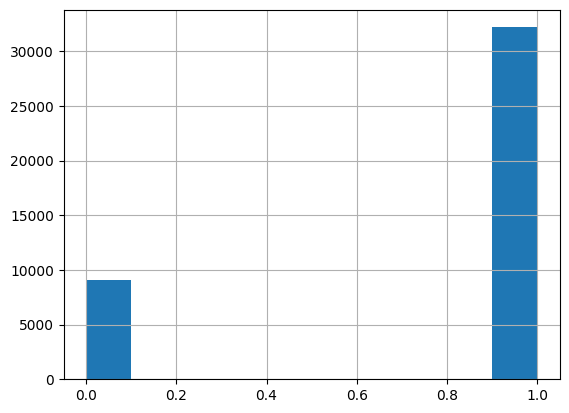

In [258]:
data['Fire Alarm'].hist()
print('Соотношение классов(1/0):', data['Fire Alarm'].sum()/data.shape[0])

Классы распределены неравномерно, воспользуемся библиотекой imbalance-learn

In [259]:
from imblearn.pipeline import Pipeline

In [260]:
X = data.drop('Fire Alarm', axis=1)
y = data['Fire Alarm']
print(X.shape, y.shape)

(41247, 12) (41247,)


In [261]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [262]:
oversample = SMOTE(random_state=42)
X_train, y_train = oversample.fit_resample(X_train, y_train)
print(X_train.shape, y_train.shape)
print(y_train.value_counts())

(51514, 12) (51514,)
Fire Alarm
1    25757
0    25757
Name: count, dtype: int64


## Logistic Regression

## kNN

In [263]:
from sklearn.neighbors import KNeighborsClassifier

Данная задача является задачей бинарной классификации, поэтому возьмем нечетное k

In [264]:

knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2) # p=2 для использования евклидового расстояния
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [265]:
y_bin_knn_pred = knn.predict(X_test)

In [266]:
accuracy_score(y_test, y_bin_knn_pred)

1.0

In [267]:
confusion_matrix(y_test, y_bin_knn_pred)

array([[1810,    0],
       [   0, 6440]])

In [268]:
print(classification_report(y_test, y_bin_knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1810
           1       1.00      1.00      1.00      6440

    accuracy                           1.00      8250
   macro avg       1.00      1.00      1.00      8250
weighted avg       1.00      1.00      1.00      8250



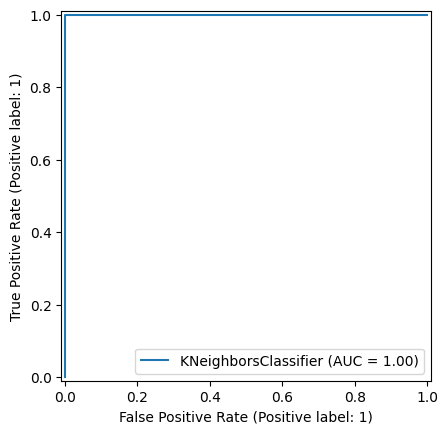

In [269]:
RocCurveDisplay.from_estimator(knn, X_test, y_test)

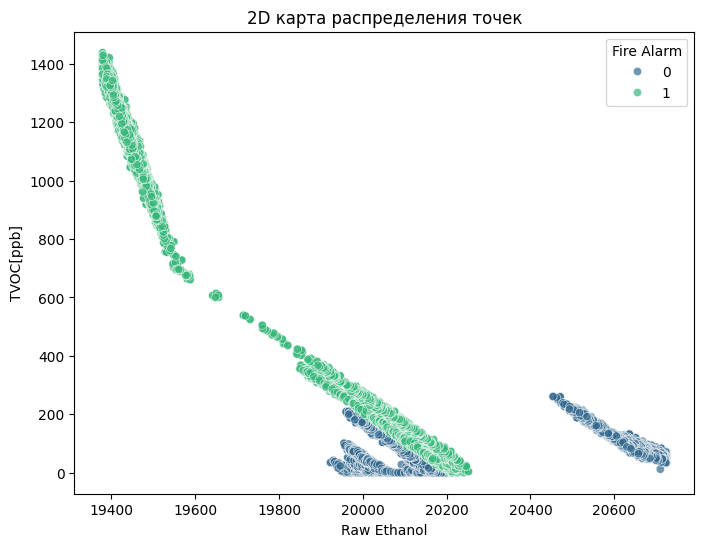

In [279]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Raw Ethanol", 
                y="TVOC[ppb]", 
                hue="Fire Alarm", 
                data=data, 
                palette="viridis", 
                alpha=0.7)
plt.title("2D карта распределения точек")
plt.xlabel("Raw Ethanol")
plt.ylabel("TVOC[ppb]")
plt.show()

## Naive Bayes